In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})

In [68]:
TEMP = 23 #celcius
HUMIDITY = 61 #%
PRESSURE = 992e2 / 133.322387415 #mmhg
DENSITY = (0.46455 * PRESSURE - 61 * (0.00252 * TEMP - 0.020582)) / (TEMP + 273.15) #kg/m3
print(DENSITY)

H_ATM = 136
H_PITOT = 14.65
CORDLENGTH = 150

plot_configs = [
    ('0', 0, 'indianred'),
    ('6', 6, 'steelblue'),
    ('m4', -4, 'lightseagreen')
]

1.1594581064279144


In [59]:
col = ['tap', 'x', 'surface', 'h0', 'h6', 'hm4']
df = pd.read_csv('naca0012_ex1.csv', sep=',', skiprows=1, names=col)

print(df)

    tap      x surface   h0   h6  hm4
0     0    0.0      LE  121  125  123
1     1    7.5   Upper  139  157  132
2     2    7.5   Lower  140  127  150
3     3   15.0   Upper  139  156  135
4     4   15.0   Lower  140  132  146
5     5   22.5   Upper  139  145  136
6     6   22.5   Lower  140  133  144
7     7   30.0   Upper  139  145  136
8     8   30.0   Lower  140  133  143
9     9   45.0   Upper  138  143  137
10   10   45.0   Lower  139  133  142
11   11   60.0   Upper  139  141  137
12   12   60.0   Lower  139  134  142
13   13   75.0   Upper  139  139  138
14   14   75.0   Lower  139  135  141
15   15   90.0   Upper  139  138  139
16   16   90.0   Lower  139  135  140
17   17  105.0   Upper  139  137  138
18   18  105.0   Lower  139  135  139
19   19  120.0   Upper  139  137  137
20   20  120.0   Lower  139  135  139


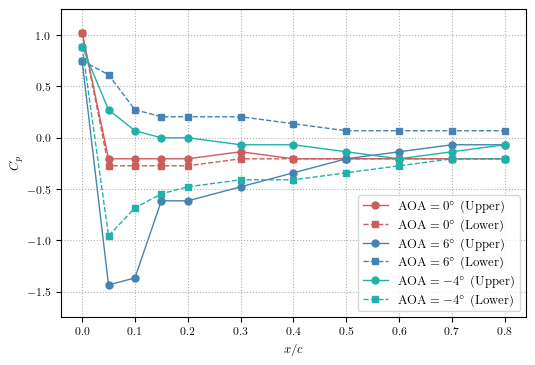

In [ ]:
df['xc'] = df['x'] / CORDLENGTH

for suffix, aoa_val, color in plot_configs:
    df[f'p{suffix}'] = 1000 * 9.81 * df[f'h{suffix}'] * 0.001
    df[f'cp{suffix}'] = (H_ATM - df[f'h{suffix}']) / H_PITOT

    df[f'dh{suffix}'] = H_ATM - df[f'h{suffix}']

df[['tap', 'dh0', 'dh6', 'dhm4']].to_csv('manometer.csv', index=False)
df[['tap', 'p0', 'p6', 'pm4']].to_csv('pressure.csv', index=False, float_format='%.2f')
df[['tap', 'xc', 'surface', 'cp0', 'cp6', 'cpm4']].to_csv('cp.csv', index=False, float_format='%.2f')

df_upper = df[df['surface'].isin(['LE', 'Upper'])]
df_lower = df[df['surface'].isin(['LE', 'Lower'])]

fig, ax = plt.subplots(figsize=(6,4))

for suffix, aoa_val, color in plot_configs:
    ax.plot(df_upper['xc'], df_upper[f'cp{suffix}'],
            label=f'$\mathrm{{AOA}}={aoa_val}^\circ$ (Upper)', marker='o', color=color, markersize=5, lw=1)
    
    ax.plot(df_lower['xc'], df_lower[f'cp{suffix}'], 
            label=f'$\mathrm{{AOA}}={aoa_val}^\circ$ (Lower)', marker='s', color=color, markersize=5, linestyle='--', lw=1)
    
ax.set_xlabel('$x/c$')
ax.set_ylabel('$C_p$')
ax.set_ylim(-1.75,1.25)
ax.legend(loc='lower right')
ax.grid(True, linestyle=':')

#fig.savefig('cp.pdf', format='pdf', bbox_inches='tight')
plt.show()

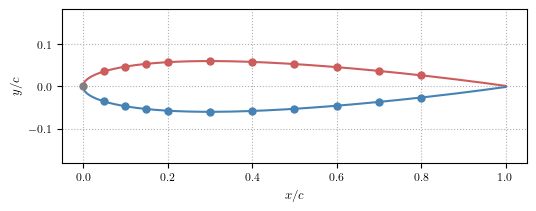

In [63]:
def naca0012_y(x, is_upper=True):
    t = 0.12
    yt = 5 * t * (0.2969 * np.sqrt(x) - 0.1260 * x - 0.3516 * x**2 + 0.2843 * x**3 - 0.1015 * x**4)
    return yt if is_upper else -yt

x = np.linspace(0, 1, 1000)

y_upper = naca0012_y(x, 1)
y_lower = naca0012_y(x, 0)

fig, ax = plt.subplots(figsize=(6,2))
ax.plot(x, y_upper, color='indianred', label='Upper Surface')
ax.plot(x, y_lower, color='steelblue', label='Lower Surface')

tap_x_raw = np.array([7.5, 15, 22.5, 30, 45, 60, 75, 90, 105, 120])
tap_x = tap_x_raw / 150.0

tap_y_upper = naca0012_y(tap_x, 1)
tap_y_lower = naca0012_y(tap_x, 0)

ax.plot(tap_x, tap_y_upper, 'o', color='indianred',  markersize=5)
ax.plot(tap_x, tap_y_lower, 'o', color='steelblue',  markersize=5)
ax.plot(0, 0, 'o', color='gray',  markersize=5)

ax.axis('equal')
ax.set_xlabel('$x/c$')
ax.set_ylabel('$y/c$')
ax.grid(True, linestyle=':')

fig.savefig('naca0012.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [84]:
df['yc'] = df.apply(lambda row: naca0012_y(row['xc'], row['surface']), axis=1)

df_upper = df[df['surface'].isin(['LE', 'Upper'])].sort_values(by='xc', ascending=False)
df_lower = df[df['surface'] == 'Lower'].sort_values(by='xc', ascending=True)

ordered_df = pd.concat([df_upper, df_lower]).reset_index(drop=True)

x = ordered_df['xc'].values
y = ordered_df['yc'].values
n_points = len(x)

x_mid = np.zeros(n_points)
y_mid = np.zeros(n_points)

for i in range(n_points):
    prev_i = (i - 1) % n_points
    x_mid[i] = (x[prev_i] + x[i]) / 2.0
    y_mid[i] = (y[prev_i] + y[i]) / 2.0

dx = np.zeros(n_points)
dy = np.zeros(n_points)

for i in range(n_points):
    next_i = (i + 1) % n_points
    dx[i] = x_mid[next_i] - x_mid[i]
    dy[i] = y_mid[next_i] - y_mid[i]

for suffix, aoa_val, color in plot_configs:
    cp_array = ordered_df[f'cp{suffix}'].values
    
    c_Fx = np.sum(-cp_array * dy)
    c_Fy = np.sum(cp_array * dx)
    
    alpha_rad = np.radians(aoa_val)
    c_l = c_Fy * np.cos(alpha_rad) - c_Fx * np.sin(alpha_rad)
    c_d = c_Fx * np.cos(alpha_rad) + c_Fy * np.sin(alpha_rad)
    
    print(f"AOA ={aoa_val:>3} : C_L ={c_l:>8.4f}, C_D ={c_d:>8.4f}, L ={c_l * 0.5 * 15.74**2 * 0.15 * DENSITY}, L ={c_d * 0.5 * 15.74**2 * 0.15 * DENSITY}")

AOA =  0 : C_L = -0.0222, C_D =  0.0028, L =-0.4779379506635816, L =0.06066173618886359
AOA =  6 : C_L =  0.4750, C_D = -0.0132, L =10.232731997622086, L =-0.28399617651902054
AOA = -4 : C_L = -0.2682, C_D =  0.0545, L =-5.7777422510901975, L =1.1738096185671938
